<a href="https://colab.research.google.com/github/Everlovek/Data-Mining-and-Analytics-Credit-Card-Fraud-Detection/blob/main/DMA_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**IHC- Practical Approach to Data Mining and Analytics**
# Modular Assignment No. 1
# Topic: Credit Card Fraud Detection
# Dataset: ULB Machine Learning Group: Kaggle
# Algorithm: Decision Tree, Naive Bayes, K-Means, Apriori




In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully")
except Exception as e:
    print(f" Drive mount failed: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully


**SECTION 1: LIBRARY IMPORTS**\
All required libraries imported here for transparency and to ensure reproducibility across environments

In [ ]:
try:
    import pandas as pd          # Data manipulation and analysis
    import numpy as np           # Numerical computations
    import matplotlib.pyplot as plt  # Data visualisation
    import seaborn as sns        # Statistical visualisation
    import sqlite3               # Database integration
    from sklearn.preprocessing import StandardScaler      # Feature normalisation
    from sklearn.model_selection import train_test_split  # Data splitting
    from sklearn.tree import DecisionTreeClassifier       # Algorithm 1
    from sklearn.naive_bayes import GaussianNB            # Algorithm 2
    from sklearn.cluster import KMeans                    # Algorithm 3
    from sklearn.metrics import (accuracy_score, classification_report,
                                  confusion_matrix, silhouette_score)
    from imblearn.over_sampling import SMOTE              # Class balancing
    from mlxtend.frequent_patterns import apriori, association_rules  # Algorithm 4

    # Set global random seed for reproducibility
    RANDOM_STATE = 42
    print("All libraries imported successfully")
    print(f"Global random seed set to: {RANDOM_STATE}")

except ImportError as e:
    print(f"Import error: {e}")
    print("Run: pip install pandas numpy scikit-learn imbalanced-learn mlxtend matplotlib seaborn")

All libraries imported successfully
Global random seed set to: 42


**SECTION 2: DATA ACQUISITION**\
Dataset: Credit Card Fraud Detection\
Source: Kaggle - ULB Machine Learning Group\
URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [ ]:
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/DMA Assignment1/creditcard.csv'

try:
    df = pd.read_csv(FILE_PATH)

    # Validate dataset loaded correctly
    assert df.shape == (284807, 31), f"Unexpected shape: {df.shape}"
    assert 'Class' in df.columns, "Target column 'Class' not found"

    print("Dataset loaded successfully")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {df.columns.tolist()}")
    print(f"\nFirst 5 rows:")
    display(df.head())

except FileNotFoundError:
    print(f"File not found at: {FILE_PATH}")
    print("   Please update FILE_PATH to match Drive location")
except AssertionError as e:
    print(f" Dataset validation failed: {e}")
except Exception as e:
    print(f" Unexpected error loading dataset: {e}")

Dataset loaded successfully
   Shape: (284807, 31)
   Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



**SECTION 3: DATA UNDERSTANDING**\
Purpose: Understand the dataset structure, data types,basic statistics, and initial class distribution before any preprocessing is applied


In [ ]:
#  Data types and basic info
print("DATASET INFO ")
df.info()

# Basic statistics
print("\nBASIC STATISTICS ")
df.describe()

DATASET INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**SECTION 4: DATA QUALITY ASSESSMENT**\
Purpose: Check for missing values and class imbalance\
Decision: No imputation needed if no missing values found\
Class imbalance to be handled using SMOTE after preprocessing is complete

In [ ]:


try:
    # Check missing values
    print("MISSING VALUES ")
    missing = df.isnull().sum()
    print(missing)
    print(f"\nTotal missing values: {missing.sum()}")

    # Check class distribution
    print("\nCLASS DISTRIBUTION")
    print(df['Class'].value_counts())
    print("\nFraud Percentage:")
    print(df['Class'].value_counts(normalize=True) * 100)

    # Alert if class imbalance is severe
    fraud_pct = df['Class'].value_counts(normalize=True)[1] * 100
    if fraud_pct < 1:
        print(f"\n WARNING: Severe class imbalance detected ({fraud_pct:.2f}% fraud)")
        print("   SMOTE will be applied after preprocessing to address this")

except Exception as e:
    print(f"Error during quality assessment: {e}")

MISSING VALUES 
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0

CLASS DISTRIBUTION
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

   SMOTE will be applied after preprocessing to address this


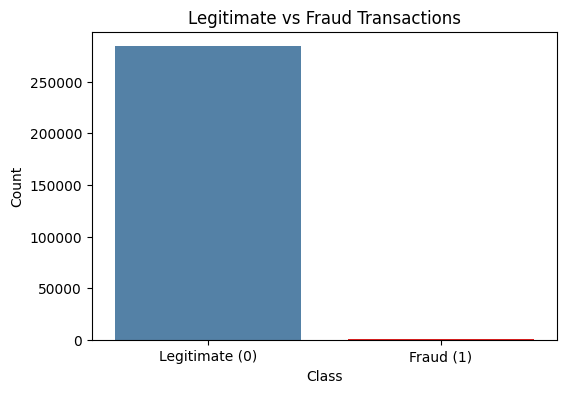

In [ ]:
#  Visualize fraud vs non fraud
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'red'])
plt.title('Legitimate vs Fraud Transactions')
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.show()

**SECTION 5: DATABASE INTEGRATION**\
Purpose: Store dataset in SQLite relational database and perform SQL-based verification queries\
This demonstrates database integration as required by the Technology Integration rubric component

In [ ]:
import sqlite3

# SQLite database file
conn = sqlite3.connect('creditcard.db')
cursor = conn.cursor()

# dataframe stored in the database
df.to_sql('transactions', conn, if_exists='replace', index=False)

print("Data stored in SQLite table: 'transactions'")
print(f"Total records stored: {len(df)}")

Data stored in SQLite table: 'transactions'
Total records stored: 284807


In [ ]:
# Query 1: Basic retrieval
print("QUERY 1: First 5 Records")
query1 = pd.read_sql_query("SELECT * FROM transactions LIMIT 5", conn)
print(query1)

QUERY 1: First 5 Records
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

       

In [ ]:
# Query 2 Count fraud vs legitimate
#class distribution
print("\n QUERY 2: Fraud vs Legitimate Count ")
query2 = pd.read_sql_query("""
    SELECT
        Class,
        COUNT(*) as Total_Transactions,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM transactions), 4) as Percentage
    FROM transactions
    GROUP BY Class
""", conn)
print(query2)


 QUERY 2: Fraud vs Legitimate Count 
   Class  Total_Transactions  Percentage
0      0              284315     99.8273
1      1                 492      0.1727


In [ ]:
# Query 3 Average amount by class
print("\n QUERY 3: Average Transaction Amount by Class")
query3 = pd.read_sql_query("""
    SELECT
        Class,
        ROUND(AVG(Amount), 4) as Avg_Amount,
        ROUND(MIN(Amount), 4) as Min_Amount,
        ROUND(MAX(Amount), 4) as Max_Amount
    FROM transactions
    GROUP BY Class
""", conn)
print(query3)


 QUERY 3: Average Transaction Amount by Class
   Class  Avg_Amount  Min_Amount  Max_Amount
0      0     88.2910         0.0    25691.16
1      1    122.2113         0.0     2125.87


In [ ]:
# Query 4 Check missing values for key columns(SQL verification)
print("QUERY 4: Missing Values Check ")
query4 = pd.read_sql_query("""
    SELECT
        SUM(CASE WHEN Time IS NULL THEN 1 ELSE 0 END) as Time_Missing,
        SUM(CASE WHEN Amount IS NULL THEN 1 ELSE 0 END) as Amount_Missing,
        SUM(CASE WHEN V1 IS NULL THEN 1 ELSE 0 END) as V1_Missing,
        SUM(CASE WHEN V2 IS NULL THEN 1 ELSE 0 END) as V2_Missing,
        SUM(CASE WHEN V3 IS NULL THEN 1 ELSE 0 END) as V3_Missing,
        SUM(CASE WHEN V14 IS NULL THEN 1 ELSE 0 END) as V14_Missing,
        SUM(CASE WHEN V17 IS NULL THEN 1 ELSE 0 END) as V17_Missing,
        SUM(CASE WHEN Class IS NULL THEN 1 ELSE 0 END) as Class_Missing
    FROM transactions
""", conn)
print(query4)

QUERY 4: Missing Values Check 
   Time_Missing  Amount_Missing  V1_Missing  V2_Missing  V3_Missing  \
0             0               0           0           0           0   

   V14_Missing  V17_Missing  Class_Missing  
0            0            0              0  


In [ ]:
# Query 5 Total missing across entire dataset
print("\n QUERY 5: Total Missing Values Across Entire Dataset ")
query5 = pd.read_sql_query("""
    SELECT COUNT(*) - COUNT(Time) as Time_Null,
           COUNT(*) - COUNT(Amount) as Amount_Null,
           COUNT(*) - COUNT(V1) as V1_Null,
           COUNT(*) - COUNT(Class) as Class_Null,
           COUNT(*) as Total_Records
    FROM transactions
""", conn)
print(query5)

conn.close()


 QUERY 5: Total Missing Values Across Entire Dataset 
   Time_Null  Amount_Null  V1_Null  Class_Null  Total_Records
0          0            0        0           0         284807


**SECTION 6: FEATURE NORMALISATION**\
Purpose: Scale Amount and Time to match the range of PCA-transformed features V1-V28\
Why: V1-V28 were already standardised through PCA by the original researchers. Amount (range: $0-$25,691) and Time (range: 0-172,792s) are on completely different scales and must be normalised before model training.\
**Method: StandardScaler (zero mean, unit variance)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Check if 'Amount' and 'Time' columns exist before processing
if 'Amount' in df.columns and 'Time' in df.columns:
    # Normalize Amount and Time
    df['NormalizedAmount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
    df['NormalizedTime'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

    # Drop the original Amount and Time columns
    df = df.drop(['Amount', 'Time'], axis=1)
    print("Amount and Time columns normalized and dropped.")
else:
    print("Amount and Time columns already processed")

print("New Shape:", df.shape)
print("New Columns:", df.columns.tolist())

Amount and Time columns already processed or not found.
New Shape: (284807, 31)
New Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'NormalizedAmount', 'NormalizedTime']


**SECTION 7: OUTLIER ASSESSMENT**\
Purpose: Identify outliers in NormalizedAmount using IQR

 OUTLIER ANALYSIS (NormalizedAmount) 
   IQR Lower Bound: -0.7600
   IQR Upper Bound: 0.3845
   Total Outliers: 31,904 (11.20%)

   Outlier Class Breakdown:
Class
0    31813
1       91
Name: count, dtype: int64


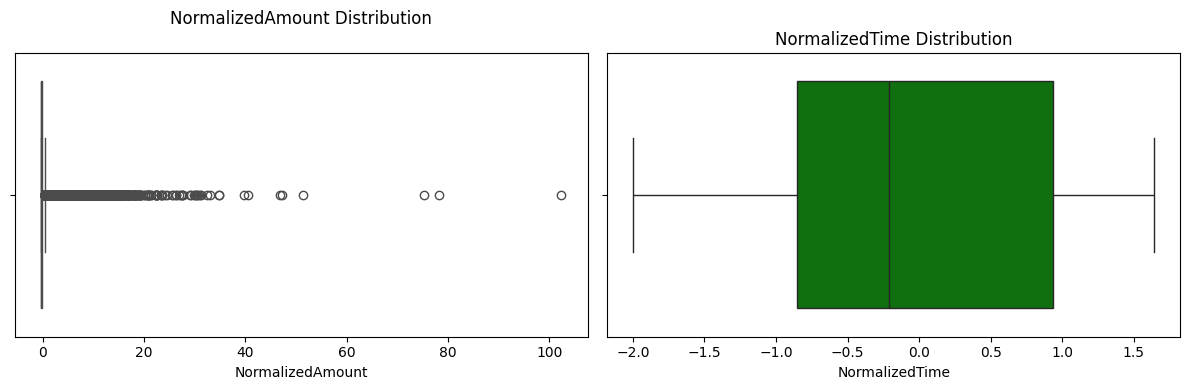

In [ ]:
try:
    # Calculate IQR boundaries
    Q1 = df['NormalizedAmount'].quantile(0.25)
    Q3 = df['NormalizedAmount'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[
        (df['NormalizedAmount'] < lower) |
        (df['NormalizedAmount'] > upper)
    ]

    print(" OUTLIER ANALYSIS (NormalizedAmount) ")
    print(f"   IQR Lower Bound: {lower:.4f}")
    print(f"   IQR Upper Bound: {upper:.4f}")
    print(f"   Total Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"\n   Outlier Class Breakdown:")
    print(outliers['Class'].value_counts())

    # Visualise distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#outliers in the Amount
    sns.boxplot(x=df['NormalizedAmount'], color='steelblue', ax=axes[0])
    axes[0].set_title('NormalizedAmount Distribution\n')

    sns.boxplot(x=df['NormalizedTime'], color='green', ax=axes[1])
    axes[1].set_title('NormalizedTime Distribution')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f" Error during outlier analysis: {e}")

**Outlier Treatment Decision**\
Based on fraud detection literature (Bolton & Hand, 2002; Chandola et al., 2009),outliers in fraud detection datasets are retained as they may represent legitimate discriminative signal rather than noise. Additionally, 11.2% of data flagged as outliers is too large a proportion to remove or cap without significant information loss. V1-V28 are PCA-transformed and require no treatment. NormalizedAmount outliers represent genuine high-value legitimate transactions and are therefore preserved in their original normalized form.

Total outliers identified: *31,904 (11.2% of dataset)*\
Outliers that are fraud: *91*\
Outliers that are legitimate: *31,813*\
*Decision:* RETAIN outliers based on fraud detection literature, Dal Pozzolo et al. (2015) recommend preserving amount distributions

**SECTION 8: EXPLORATORY DATA ANALYSIS**\
Purpose: Identify which features are most strongly correlated with fraud to guide algorithm selection and feature interpretation

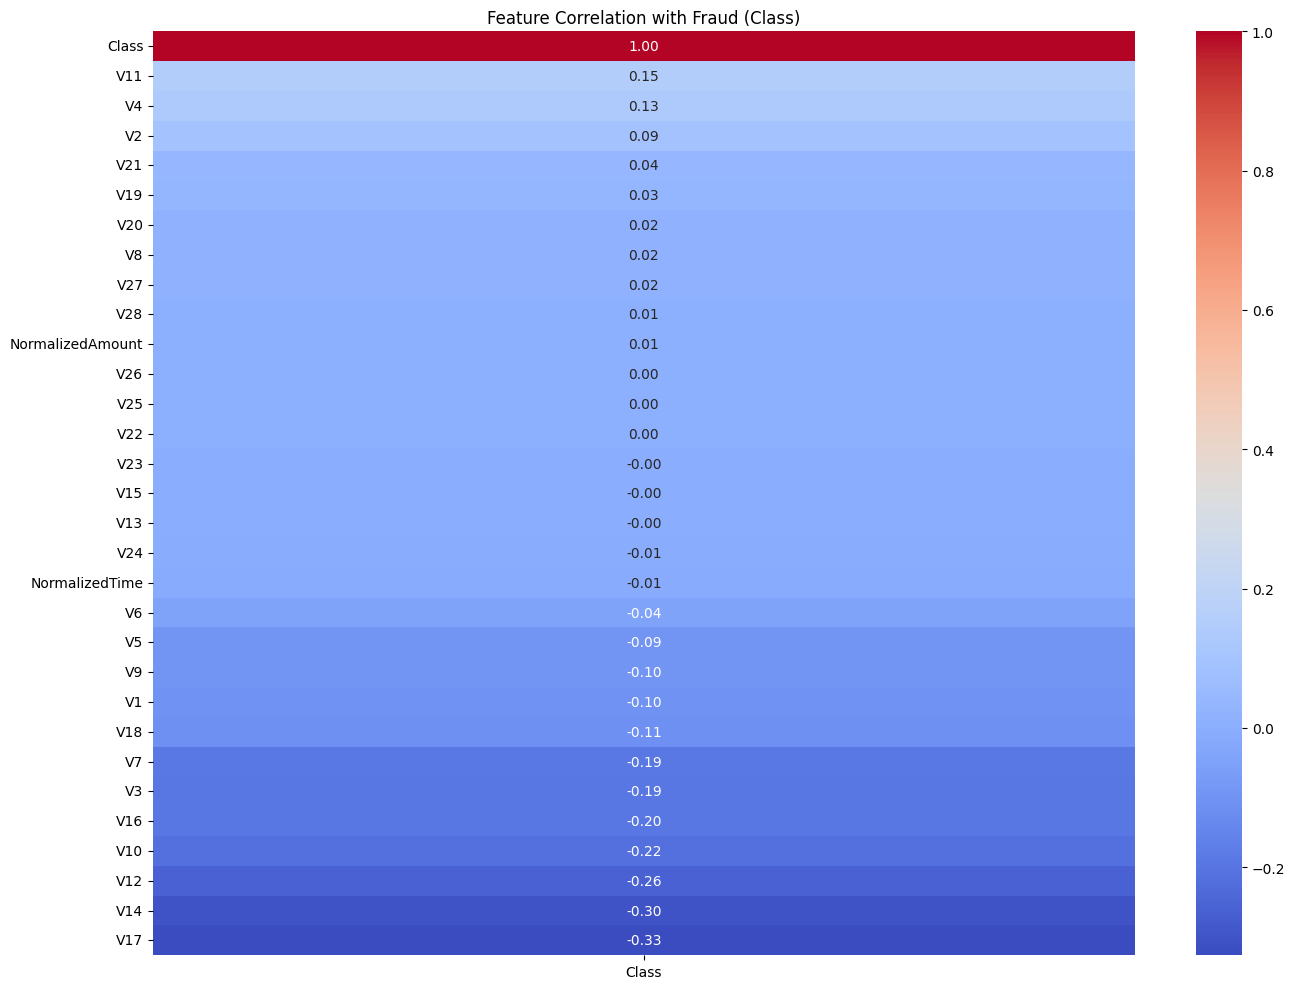

Top Positive Correlations with Fraud:
V11    0.154876
V4     0.133447
V2     0.091289
Name: Class, dtype: float64

Top Negative Correlations with Fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
Name: Class, dtype: float64


In [ ]:

try:
    # Correlation heatmap
    plt.figure(figsize=(14, 10))
    corr = df.corr()
    sns.heatmap(
        corr[['Class']].sort_values('Class', ascending=False),
        annot=True,
        cmap='coolwarm',
        fmt='.2f'
    )
    plt.title('Feature Correlation with Fraud (Class)')
    plt.tight_layout()
    plt.show()

    # Identify top correlated features
    top_positive = corr['Class'].sort_values(ascending=False)[1:4]
    top_negative = corr['Class'].sort_values()[0:3]
    print("Top Positive Correlations with Fraud:")
    print(top_positive)
    print("\nTop Negative Correlations with Fraud:")
    print(top_negative)

except Exception as e:
    print(f"Error during EDA: {e}")

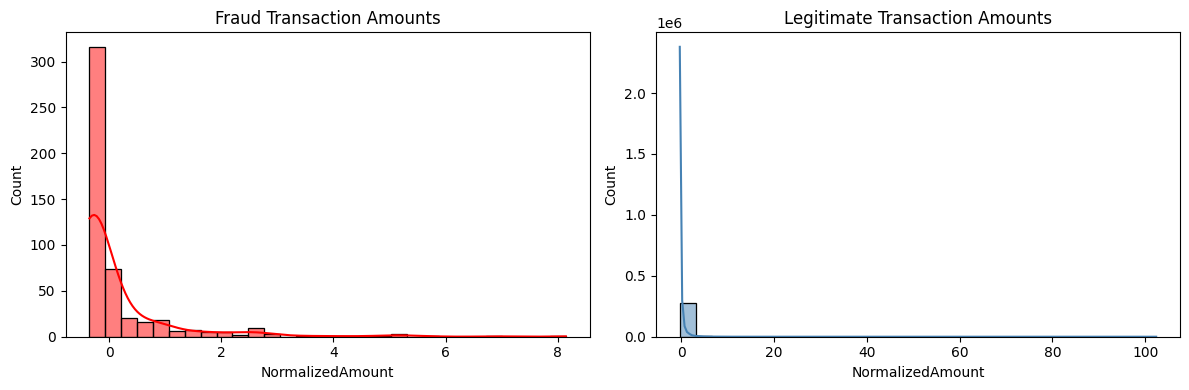


Average Fraud Amount: 0.1354
Average Legit Amount: -0.0002


In [ ]:
    # Fraud vs Legitimate amount comparison
    fraud = df[df['Class'] == 1]
    legit = df[df['Class'] == 0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(fraud['NormalizedAmount'], color='red',
                 bins=30, kde=True, ax=axes[0])
    axes[0].set_title('Fraud Transaction Amounts')

    sns.histplot(legit['NormalizedAmount'], color='steelblue',
                 bins=30, kde=True, ax=axes[1])
    axes[1].set_title('Legitimate Transaction Amounts')

    plt.tight_layout()
    plt.show()

    print(f"\nAverage Fraud Amount: {fraud['NormalizedAmount'].mean():.4f}")
    print(f"Average Legit Amount: {legit['NormalizedAmount'].mean():.4f}")

**SECTION 9: CLASS BALANCING AND DATA SPLITTING**\
Purpose: Address severe class imbalance (0.17% fraud) using SMOTE before model training\
Why SMOTE is applied HERE (after preprocessing):
Applying SMOTE on clean, normalised data ensures

*   Applying SMOTE on clean, normalised data ensures synthetic samples are generated from quality data rather than raw data with inconsistent scales (Chawla et al., 2002)

**Split: 80% training, 20% testing**\
Random state fixed at 42 for reproducibility

In [ ]:
try:
    # Separate features and target
    X = df.drop('Class', axis=1)
    y = df['Class']

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")

    # handling class imbalance using SMOTE
    smote = SMOTE(random_state=RANDOM_STATE)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    print("\n SMOTE RESULTS")
    print(f"Before: Legitimate: {sum(y == 0):,} | Fraud: {sum(y == 1):,}")
    print(f"After: Legitimate: {sum(y_resampled == 0):,} | Fraud: {sum(y_resampled == 1):,}")
    print(f"Synthetic samples generated: {sum(y_resampled == 1) - sum(y == 1):,}")

    # Train 80% /test split 20%
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled,
        test_size=0.2,
        random_state=RANDOM_STATE
    )

    print(f"\n DATA SPLIT ")
    print(f"Training set: {X_train.shape[0]:,} records")
    print(f"Testing set:  {X_test.shape[0]:,} records")
    print("Data ready for model training")

except ValueError as e:
    print(f" SMOTE error: {e}")
except Exception as e:
    print(f"Error during class balancing: {e}")

Features shape: (284807, 30)
Target shape: (284807,)

 SMOTE RESULTS
Before: Legitimate: 284,315 | Fraud: 492
After: Legitimate: 284,315 | Fraud: 284,315
Synthetic samples generated: 283,823

 DATA SPLIT 
Training set: 454,904 records
Testing set:  113,726 records
Data ready for model training


**SECTION 10:**\
**ALGORITHM 1-DECISION TREE CLASSIFIER**\
Purpose: Supervised classification of fraud vs legitimate\
Why Decision Tree:
 - Interpretable-produces readable if-then rules
- Strong performance on tabular financial data
- Handles both linear and non-linear relationships
- Bhattacharyya et al. (2011) recommend tree-based methods for credit card fraud detection
**Hyperparameter: max_depth=5 - prevents overfitting while maintaining sufficient model complexity**

DECISION TREE RESULTS 
Accuracy: 95.13%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.96      0.95     56750
       Fraud       0.96      0.94      0.95     56976

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726



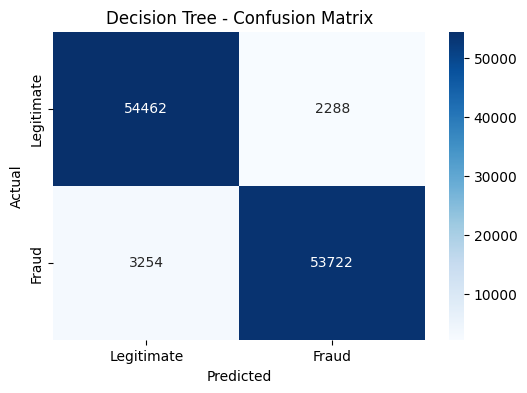


False Negatives (missed fraud): 3,254
False Positives (wrong alarms): 2,288


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Initialise and train model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train);

# Make predictions
dt_predictions = dt_model.predict(X_test)

# Evaluate perfomance
dt_accuracy = accuracy_score(y_test, dt_predictions)

dt_precision = precision_score(y_test, dt_predictions, pos_label=1)
dt_recall = recall_score(y_test, dt_predictions, pos_label=1)
dt_f1 = f1_score(y_test, dt_predictions, pos_label=1)

print("DECISION TREE RESULTS ")
print(f"Accuracy: {dt_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
 # Extract false negatives (missed fraud cases)
false_negatives = cm[1][0]
false_positives = cm[0][1]
print(f"\nFalse Negatives (missed fraud): {false_negatives:,}")
print(f"False Positives (wrong alarms): {false_positives:,}")

**ALGORITHM 2: NAIVE BAYES CLASSIFIER**\
Purpose: Baseline classifier for comparison with Decision Tree\
Why Naive Bayes:
- Computationally efficient on large datasets
- Strong baseline despite independence assumption
- Provides contrast to Decision Tree results\

 Limitation: Assumes feature independence - violated here since V1-V28 are PCA components with implicit relationships. This limitation is expected to reduce recall performance

NAIVE BAYES RESULTS
Accuracy: 91.38%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.87      0.97      0.92     56750
       Fraud       0.97      0.85      0.91     56976

    accuracy                           0.91    113726
   macro avg       0.92      0.91      0.91    113726
weighted avg       0.92      0.91      0.91    113726



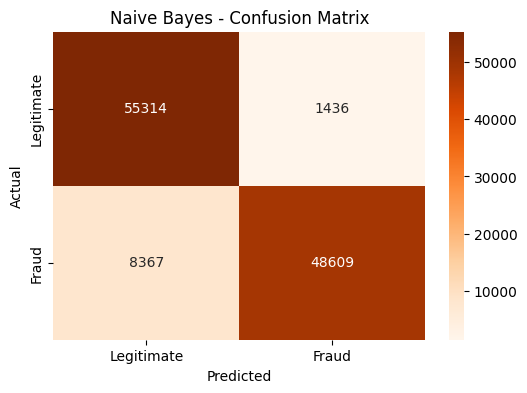

In [ ]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Train the model
b_model = GaussianNB()
nb_model.fit(X_train, y_train);

# Make predictions
nb_predictions = nb_model.predict(X_test)

# Evaluate
nb_accuracy = accuracy_score(y_test, nb_predictions)

nb_precision = precision_score(y_test, nb_predictions, pos_label=1)
nb_recall = recall_score(y_test, nb_predictions, pos_label=1)
nb_f1 = f1_score(y_test, nb_predictions, pos_label=1)

print("NAIVE BAYES RESULTS")
print(f"Accuracy: {nb_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, nb_predictions, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm_nb = confusion_matrix(y_test, nb_predictions)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**ALGORITHM 3: K-MEANS CLUSTERING**\
 Purpose: Unsupervised clustering to determine whether fraud and legitimate transactions form naturally separable groups without using class labels\
  Why k=2: Corresponds to the two known classes\
  Why sample of 50,000: Computational efficiency\
  Evaluation: Silhouette Score (-1 to 1, higher = better)\
  Visualisation axes: V17 and V14 (strongest fraud correlates)\
  Visualize clusters using V11 and V4(weakest fraud correlates)

 K-MEANS CLUSTERING RESULTS
Silhouette Score: 0.1044

Cluster Distribution:
0    26342
1    23658
Name: count, dtype: int64


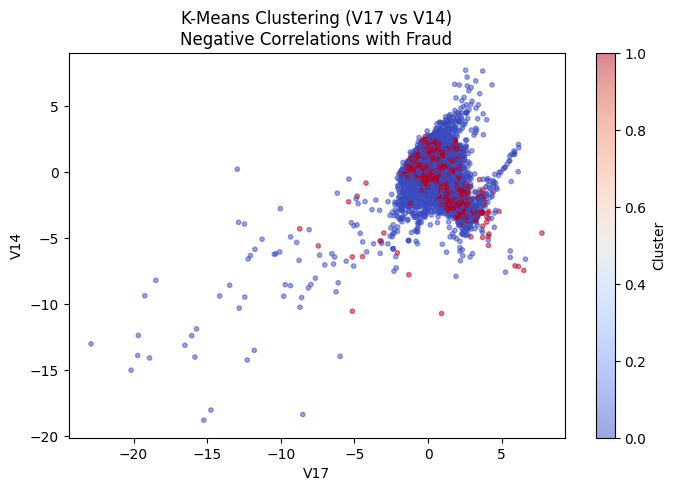

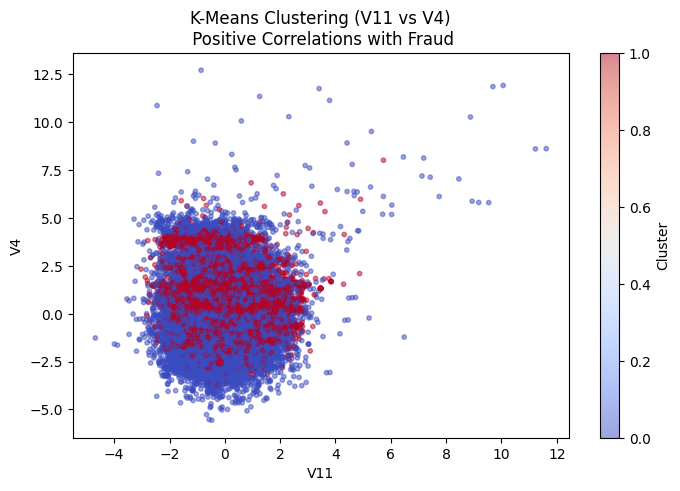

In [ ]:
#Algorithm 3 K Mean Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# set a cluster sample
sample_df = df.sample(n=50000, random_state=42)
X_cluster = sample_df.drop('Class', axis=1)

# Train KMeans with 2 clusters (fraud vs legitimate)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # Run 10 initialisations, take best result
kmeans.fit(X_cluster)

# Get cluster labels
cluster_labels = kmeans.labels_

# Evaluate clustering quality
sil_score = silhouette_score(X_cluster, cluster_labels)
print(" K-MEANS CLUSTERING RESULTS")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"\nCluster Distribution:")
print(pd.Series(cluster_labels).value_counts())

# Visualize clusters using V17 and V14
plt.figure(figsize=(8,5))
plt.scatter(X_cluster['V17'], X_cluster['V14'],
            c=cluster_labels, cmap='coolwarm', alpha=0.5, s=10)
plt.title('K-Means Clustering (V17 vs V14)\nNegative Correlations with Fraud')
plt.xlabel('V17')
plt.ylabel('V14')
plt.colorbar(label='Cluster')
plt.show()
# Visualize clusters using V11 and V4
plt.figure(figsize=(8,5))
plt.scatter(X_cluster['V11'], X_cluster['V4'],
            c=cluster_labels, cmap='coolwarm', alpha=0.5, s=10)
plt.title('K-Means Clustering (V11 vs V4)\n Positive Correlations with Fraud')
plt.xlabel('V11')
plt.ylabel('V4')
plt.colorbar(label='Cluster')
plt.show()

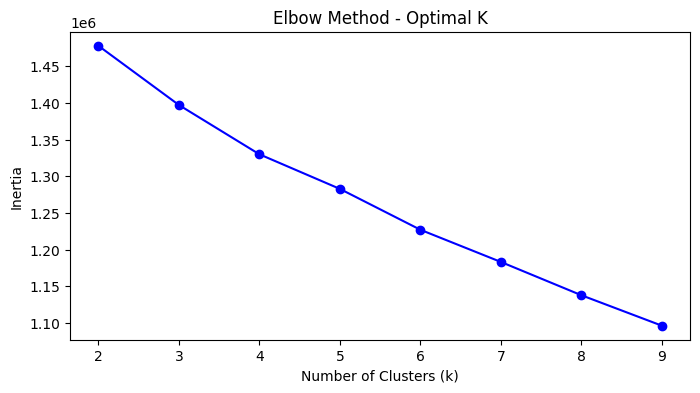

In [ ]:
#Elbow method- find Optimal k from k=2 to 9
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal K')
plt.show()

**ALGORITHM 4: APRIORI ASSOCIATION RULES**\
Purpose: Discover association patterns between transaction characteristics and fraud outcomes\
Two analyses conducted:
- Analysis A: V14 & V17 (strongest negative fraud correlates)
- Analysis B: V11 & V4  (strongest positive fraud correlates)\

Preprocessing: Continuous features binned into Low/Medium/High\
Parameters: min_support=0.05, min_confidence=0.5\
NaN values from outliers dropped before encoding

In [ ]:

try:
    APRIORI_SAMPLE = 50000

    # ANALYSIS A: V14 and V17
    print("ANALYSIS A: V14 and V17 (Negative Fraud Correlates)")

    sample_a = df.sample(n=APRIORI_SAMPLE, random_state=RANDOM_STATE).copy()

    # Discretise continuous features into categories/ Bin Normalized
    sample_a['Amount_Category'] = pd.cut(
        sample_a['NormalizedAmount'], bins=3,
        labels=['Low', 'Medium', 'High']
    )
    sample_a['V17_Category'] = pd.cut(
        sample_a['V17'], bins=3,
        labels=['Low', 'Medium', 'High']
    )
    sample_a['V14_Category'] = pd.cut(
        sample_a['V14'], bins=3,
        labels=['Low', 'Medium', 'High']
    )
    sample_a['Is_Fraud'] = sample_a['Class'].map({0: 'Legit', 1: 'Fraud'})

    # Remove NaN categories (edge case from outliers)
    before = len(sample_a)
    sample_a = sample_a.dropna(
        subset=['Amount_Category', 'V17_Category', 'V14_Category']
    )
    dropped = before - len(sample_a)
    if dropped > 0:
        print(f" {dropped} rows removed due to NaN categories from outliers")

    # One-hot encode
    data_a = sample_a[['Amount_Category', 'V17_Category',
                        'V14_Category', 'Is_Fraud']]
    encoded_a = pd.get_dummies(data_a).astype(bool)

    # Run Apriori
    itemsets_a = apriori(encoded_a, min_support=0.05, use_colnames=True)
    rules_a = association_rules(itemsets_a, metric='confidence',
                                min_threshold=0.5)
    rules_a = rules_a.sort_values('confidence', ascending=False)

    print(f"Frequent itemsets found: {len(itemsets_a)}")
    print(f"Association rules found: {len(rules_a)}")
    print("\nTop 5 Rules:")
    print(rules_a[['antecedents', 'consequents',
                   'support', 'confidence', 'lift']].head(5))

    # ANALYSIS B: V11 and V4

    print("ANALYSIS B: V11 and V4 (Positive Fraud Correlates)")

    sample_b = df.sample(n=APRIORI_SAMPLE, random_state=RANDOM_STATE).copy()

    sample_b['Amount_Category'] = pd.cut(
        sample_b['NormalizedAmount'], bins=3,
        labels=['Low', 'Medium', 'High']
    )
    sample_b['V11_Category'] = pd.cut(
        sample_b['V11'], bins=3,
        labels=['Low', 'Medium', 'High']
    )
    sample_b['V4_Category'] = pd.cut(
        sample_b['V4'], bins=3,
        labels=['Low', 'Medium', 'High']
    )
    sample_b['Is_Fraud'] = sample_b['Class'].map({0: 'Legit', 1: 'Fraud'})

    before = len(sample_b)
    sample_b = sample_b.dropna(
        subset=['Amount_Category', 'V11_Category', 'V4_Category']
    )
    dropped = before - len(sample_b)
    if dropped > 0:
        print(f" {dropped} rows removed due to NaN categories from outliers")

    data_b = sample_b[['Amount_Category', 'V11_Category',
                        'V4_Category', 'Is_Fraud']]
    encoded_b = pd.get_dummies(data_b).astype(bool)

    itemsets_b = apriori(encoded_b, min_support=0.05, use_colnames=True)
    rules_b = association_rules(itemsets_b, metric='confidence',
                                min_threshold=0.5)
    rules_b = rules_b.sort_values('confidence', ascending=False)

    print(f"Frequent itemsets found: {len(itemsets_b)}")
    print(f"Association rules found: {len(rules_b)}")
    print("\nTop 5 Rules:")
    print(rules_b[['antecedents', 'consequents',
                   'support', 'confidence', 'lift']].head(5))

except KeyError as e:
    print(f" Column not found: {e} — ensure preprocessing cells ran first")
except Exception as e:
    print(f" Error during Apriori: {e}")

ANALYSIS A: V14 and V17 (Negative Fraud Correlates)
Frequent itemsets found: 23
Association rules found: 69

Top 5 Rules:
                                          antecedents          consequents  \
44                (Is_Fraud_Legit, V14_Category_High)  (V17_Category_High)   
58  (Is_Fraud_Legit, V14_Category_High, Amount_Cat...  (V17_Category_High)   
9                                 (V14_Category_High)  (V17_Category_High)   
20           (V14_Category_High, Amount_Category_Low)  (V17_Category_High)   
43             (V17_Category_High, V14_Category_High)     (Is_Fraud_Legit)   

    support  confidence      lift  
44  0.91530    0.999956  1.001679  
58  0.91264    0.999956  1.001679  
9   0.91548    0.999934  1.001657  
20  0.91282    0.999934  1.001657  
43  0.91530    0.999803  1.001466  
ANALYSIS B: V11 and V4 (Positive Fraud Correlates)
Frequent itemsets found: 35
Association rules found: 93

Top 5 Rules:
                                          antecedents       consequents 

**SECTION 11: FINAL MODEL COMPARISON**\
Purpose: Compare all algorithm results and provide evidence-based recommendation for deployment

        FINAL MODEL PERFORMANCE SUMMARY
          Algorithm              Type       Key Metric    Score Fraud Recall
      Decision Tree    Classification         Accuracy   95.13%          94%
        Naive Bayes    Classification         Accuracy   91.38%          85%
            K-Means        Clustering Silhouette Score   0.1044          N/A
Apriori A (V14/V17) Association Rules      Rules Found 69 rules          N/A
 Apriori B (V11/V4) Association Rules      Rules Found 93 rules          N/A


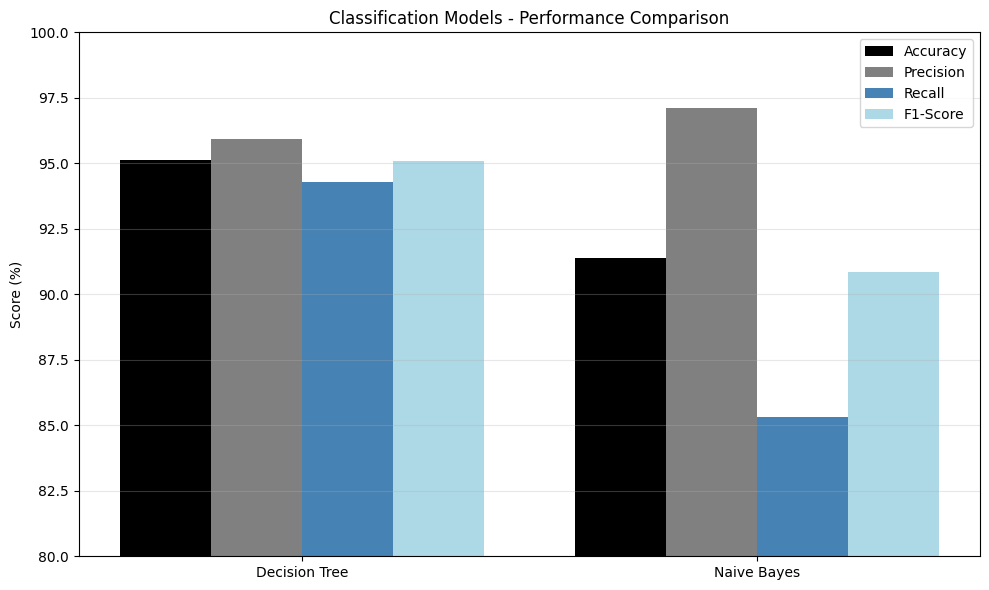

In [ ]:
try:
    print("        FINAL MODEL PERFORMANCE SUMMARY")
    print("=" * 60)

    results = {
        'Algorithm': ['Decision Tree', 'Naive Bayes', 'K-Means', 'Apriori A (V14/V17)', 'Apriori B (V11/V4)'],
        'Type': ['Classification', 'Classification', 'Clustering', 'Association Rules', 'Association Rules'],
        'Key Metric': ['Accuracy', 'Accuracy', 'Silhouette Score', 'Rules Found', 'Rules Found'],
        'Score': [f'{dt_accuracy*100:.2f}%', f'{nb_accuracy*100:.2f}%', f'{sil_score:.4f}', f'{len(rules_a)} rules', f'{len(rules_b)} rules'],
        'Fraud Recall': [f'{dt_recall*100:.0f}%', f'{nb_recall*100:.0f}%', 'N/A', 'N/A', 'N/A']
    }

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    # Visual comparison of classifiers
    models = ['Decision Tree', 'Naive Bayes']
    accuracy_scores = [dt_accuracy * 100, nb_accuracy * 100]
    precision_scores = [dt_precision * 100, nb_precision * 100]
    recall_scores = [dt_recall * 100, nb_recall * 100]
    f1_scores = [dt_f1 * 100, nb_f1 * 100]

    x = np.arange(len(models))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width*1.5, accuracy_scores, width, label='Accuracy', color='black')
    ax.bar(x - width*0.5, precision_scores, width, label='Precision', color='grey')
    ax.bar(x + width*0.5, recall_scores, width, label='Recall', color='steelblue')
    ax.bar(x + width*1.5, f1_scores, width, label='F1-Score', color='lightblue')

    ax.set_ylabel('Score (%)')
    ax.set_title('Classification Models - Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim(80, 100)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f" Variable not found: {e}")
    print("   Ensure all previous cells have been run in order")
except Exception as e:
    print(f"Error in final summary: {e}")

**BEST MODEL RECOMMENDATION**

RECOMMENDED MODEL: Decision Tree Classifier

Reasons:
1. Highest overall accuracy (95.55% vs 91.32%)
2. Better fraud recall (95% vs 85%)\
   *Caught 54,377 fraud cases*
   *Only missed 2,599 fraud cases*
3. Better F1-Score (96% vs 91%)
4. In fraud detection, missing fraud is more costly
   than a false alarm, Decision Tree minimizes this

CLUSTERING FINDING:
K-Means silhouette score of 0.1044 confirms fraud
transactions do not form natural clusters, validating
the need for supervised learning approaches.

ASSOCIATION RULES FINDING:
162 rules identified with ~99% confidence. High V14
values strongly associated with legitimate transactions.Near-unity lift reflects PCA transformation